<a href="https://colab.research.google.com/github/Lmarra1/sympy-workshop-UC3M-2025/blob/main/pendulum_equations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**The objective:**

We want to derive the equations of motion of a simple pendulum, i.e., a point mass $m$ attached to the end of a rigid, massless rod of length $L$, swinging under the action of gravity. No dissipative forces considered.

--------------------------------------
**Definition of variables:**

$L$ -- length of the pendulum rod (distance from the fixed pivot to the mass)

$\theta$ -- angular displacement of the pendulum (positive counterclockwise)

$m$ -- mass of the pendulum bob

$g$ -- gravitational acceleration

**N.B:** We adopt a Cartesian reference frame whose origin corresponds to the pendulum’s lowest equilibrium position ($\theta = 0$, where $x = 0$ and $y = 0$).

A schematic of the pendulum is shown in the following figure.


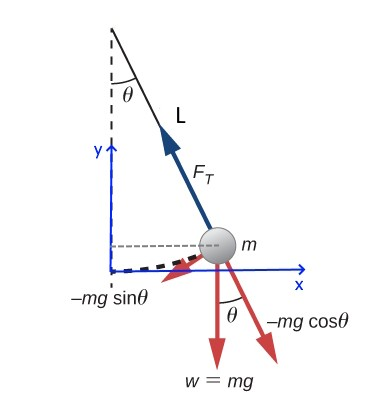

----------------------------------------
**Deriving the equations of motion:**


The dynamics of the pendulum can be obtained in two different ways:

**1) Newton’s second law** (force balance along tangential direction)

The tangential acceleration is:
$$ a_t = L \ddot{\theta} $$

The tangential component of the gravitational force is:
$$ F_t = - m g \sin(\theta) $$
(the minus sign indicates that gravity tends to restore $\theta$ toward zero).

Applying Newton’s second law $m a_t = F_t$:
$$ m L \ddot{\theta} + m g \sin(\theta) = 0 $$

Dividing by $m L$:
$$ \ddot{\theta} + \frac{g}{L} \sin(\theta) = 0 $$


**2) Euler–Lagrange formulation**


Here $\theta$ is the generalized coordinate used in the Lagrangian formulation.

We define the Lagrangian as:
$$ \mathcal{L} = T - V $$

Kinetic energy:
$$ T = \frac{1}{2} m L^2 \dot{\theta}^2 $$

Potential energy:
$$ V = m g L \left(1 - \cos(\theta)\right) $$

The Euler–Lagrange equation for the generalized coordinate $q$ is:
$$ \frac{d}{dt}\left( \frac{\partial \mathcal{L}}{\partial \dot{q}} \right)
   - \frac{\partial \mathcal{L}}{\partial q} = 0 $$

Assuming the generalized coordinate $q:=\theta$ and valuating the derivatives leads again to:
$$ \ddot{\theta} + \frac{g}{L} \sin(\theta) = 0 $$


-------------------------

**What happens if we apply the small-angle approximation??**

For small angular displacements $\sin(\theta) \approx \theta$, the nonlinear equation simplifies to the linearized form:
$$ \ddot{\theta} + \frac{g}{L} \theta = 0 $$

-------------------------
We can derive this directly using sympy! The approach involving Euler-Lagrange equations will be useful later for more difficult cases...


**Let's do it!!!**




In [2]:
# Import sympy package
import sympy as sp

In [3]:
# Define the physical variables
t       = sp.Symbol('t', real=True)         # Time  (real variable)
m       = sp.Symbol('m', positive=True)     # Mass  (real positive variable)
g       = sp.Symbol('g', positive=True)     # Gravity (real positive variable)
L       = sp.Symbol('L', positive=True)     # Rod lenght (real positive variable)
theta   = sp.Function('theta')(t)           # Angle theta defined as a time-dependent variable

# Transformation to cartesian coordinates
x       = L * sp.sin(theta)
y       = L * (1 - sp.cos(theta))

# Position vector
r = sp.Matrix([x, y])

# Velocity vector
v = r.diff(t)           # .diff(t) command to calculate the derivative of "r" wrt "t"


In [4]:
# 1. Pretty print in the console
print('\nVelocity vector (pprint format):')
sp.pprint(v)

# 2. Display in Jupyter Notebook (fancier output)
from IPython.display import display
print('\nVelocity vector (display format):')
display(v)

# 3. LaTeX string output
print('\nVelocity vector (LaTeX string):')
latex_str = sp.latex(v)
print(latex_str)

# 4. Using str() for normal string
print('\nVelocity vector (str format):')
print(str(v))


Velocity vector (pprint format):
⎡            d       ⎤
⎢L⋅cos(θ(t))⋅──(θ(t))⎥
⎢            dt      ⎥
⎢                    ⎥
⎢            d       ⎥
⎢L⋅sin(θ(t))⋅──(θ(t))⎥
⎣            dt      ⎦

Velocity vector (display format):


Matrix([
[L*cos(theta(t))*Derivative(theta(t), t)],
[L*sin(theta(t))*Derivative(theta(t), t)]])


Velocity vector (LaTeX string):
\left[\begin{matrix}L \cos{\left(\theta{\left(t \right)} \right)} \frac{d}{d t} \theta{\left(t \right)}\\L \sin{\left(\theta{\left(t \right)} \right)} \frac{d}{d t} \theta{\left(t \right)}\end{matrix}\right]

Velocity vector (str format):
Matrix([[L*cos(theta(t))*Derivative(theta(t), t)], [L*sin(theta(t))*Derivative(theta(t), t)]])


In [5]:

v_sq = (v.dot(v)).expand()

print('\n Velocity vector squared\n')
display(v_sq)

print('\n We can simplify the expression...\n')
display(sp.simplify(v_sq))


 Velocity vector squared



L**2*sin(theta(t))**2*Derivative(theta(t), t)**2 + L**2*cos(theta(t))**2*Derivative(theta(t), t)**2


 We can simplify the expression...



L**2*Derivative(theta(t), t)**2

In [6]:
# Kinetic and potential energy
T = sp.simplify(sp.Rational(1,2)*m*(v.dot(v)) )
V = m*g*L*(1 - sp.cos(theta))
Lag = T - V

# Display energies
print("\nKinetic Energy T:\n")
display(T)

print("\nPotential Energy V:\n")
display(V)

print("\nLagrangian L = T - V:\n")
display(Lag)


Kinetic Energy T:



L**2*m*Derivative(theta(t), t)**2/2


Potential Energy V:



L*g*m*(1 - cos(theta(t)))


Lagrangian L = T - V:



L**2*m*Derivative(theta(t), t)**2/2 - L*g*m*(1 - cos(theta(t)))

In [7]:
from IPython.display import Math

# Euler–Lagrange for theta
EL_theta = sp.simplify(sp.diff(sp.diff(Lag, theta.diff(t)), t) - sp.diff(Lag, theta))

display(Math(r'\text{Equation in } \theta:'))
print('')
display(Math(sp.latex(EL_theta)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [19]:
theta_dd  =  sp.diff(theta, (t, 2))                           # We want to simplify this expression wrt the coefficients of theta_dot_dot
coeff_theta_dd = sp.simplify(sp.expand(EL_theta).coeff(theta_dd))

print("\nCoefficient of theta_dd:\n")
display(coeff_theta_dd)

EL_simplified = EL_theta / coeff_theta_dd

print("\nSimplified equation in theta:\n")
display(sp.simplify(EL_simplified))


Coefficient of theta_dd:



L**2*m


Simplified equation in theta:



Derivative(theta(t), (t, 2)) + g*sin(theta(t))/L

In [21]:
EL_theta_equation = sp.Eq(EL_simplified, 0)


print("\n Visualizing it as an equation: \n")
display(sp.simplify(EL_theta_equation))


 Visualizing it as an equation: 



Eq(Derivative(theta(t), (t, 2)) + g*sin(theta(t))/L, 0)

In [23]:
sol_theta = sp.solve(EL_simplified, theta_dd)              # If we want to isolate the term with theta_dot_dot
theta_dd_simpl = sp.simplify(sp.trigsimp(sol_theta[0]))


print("\n RHS of the equation:\n")
display(theta_dd_simpl)


 RHS of the equation:



-g*sin(theta(t))/L